In [2]:
import numpy as np

In [6]:
# least square y = -ax+b
# input data
x = np.array([0,1,2,3]) # 하나의 feature 를 의미함.
y = np.array([-1,0.2,0.9,2.1])

In [7]:
# concatenate a constant term (bias값)
A = np. vstack([x, np.ones(len(x))]).T

In [8]:
A

array([[0., 1.],
       [1., 1.],
       [2., 1.],
       [3., 1.]])

In [9]:
# create a matrix
At_A = A.T.dot(A) #A.T 와 A의 행렬 곱셈결과.
At_A

array([[14.,  6.],
       [ 6.,  4.]])

In [10]:
# create a vector A'*b
At_y = A.T.dot(y)
At_y

array([8.3, 2.2])

In [16]:
# solve for x
# 이렇게 하는 이유는, At_A.dot(A).dot(x) = At_A.dot(y)인 normal equation을 바로 적용했기 때문임.
from numpy.linalg import solve
c = solve(At_A, At_y)
c
# y = ax + b 에서 가중치에 해당하는 값들임. 최적의 솔루션

array([ 1.  , -0.95])

In [17]:
# fitted value
y_fitted = A.dot(c)
y_fitted
# 최적의 근사값을 찾아낸 결과.

array([-0.95,  0.05,  1.05,  2.05])

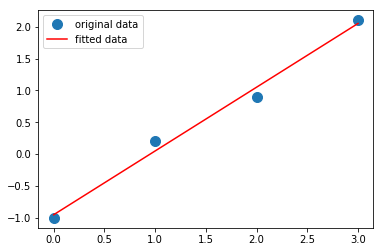

In [19]:
import matplotlib.pyplot as plt
plt.plot(x,y,'o', label = 'original data', markersize = 10)
plt.plot(x,y_fitted, 'r', label = 'fitted data')
plt.legend()
plt.show()

In [20]:
# compute error vector
error = y - y_fitted
error

array([-0.05,  0.15, -0.15,  0.05])

In [21]:
#calculate Error
np.sqrt(np.sum(error**2))
# 이 값은 에러 최소값이다.

0.22360679774997896

In [23]:
from numpy.linalg import norm
norm(y-y_fitted)

0.22360679774997896

In [22]:
#example in the slide
A = np.array([[60,5.5,1],[65,4.8,0],[55,6.0,1],[50,5.0,1]])
b = np.array([66,70,78,72])

In [24]:
At_A = A.T.dot(A)
At_A

array([[1.3350e+04, 1.2220e+03, 1.6500e+02],
       [1.2220e+03, 1.1429e+02, 1.6500e+01],
       [1.6500e+02, 1.6500e+01, 3.0000e+00]])

In [25]:
At_b = A.T.dot(b)

In [27]:
x = solve(At_A, At_b)
x

array([-0.12459016, 16.06557377, -9.50819672])

In [28]:
b_fitted = A.dot(x)
b_fitted

array([71.37704918, 69.01639344, 80.03278689, 64.59016393])

In [30]:
error = b-b_fitted
error

array([-5.37704918,  0.98360656, -2.03278689,  7.40983607])

In [31]:
np.sqrt(np.sum(error**2))

9.429635877746556

In [32]:
norm(b-b_fitted)

9.429635877746556

gradient descent로도 구할 수 있고, normal equation으로도 값을 구할 수 있는데

normal equation으로 답을 구하는 건 'analytic solution'이라고 부른다. 구하고자 하는 해가 공식에 대입하면 그대로 나오는 경우에 해당함.
(근의 공식과 비슷한 개념)

least square에서는 normal equation이 근의 공식에 대응한다.
단 analytic solution이 없는 경우는 gradient descent를 통해 해에 근접해야 한다.

장단점?

공식으로 값을 구할 경우 .... inverse값이 필요하기에 연산이 까다롭다. gradient descent보다 반드시 빠르다고 할 수 없는 셈.
row보다 column값이 많은 경우... At_A.dot(A)하면 매트릭스가 엄청 커진다.
이걸 그대로 때려박을 수 없으니 QR변형 같은 방법들을 통해 직접 저 큰 연산을 하지 않고도 값을 얻어내는 방법들이 있긴 하다고.